In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [156]:
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [157]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [158]:
df.shape

(19158, 13)

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [160]:
cca_criteria_cols = [col for col in df.columns if df[col].isnull().mean()*100 < 5 and df[col].isnull().mean()*100 > 0]
cca_criteria_cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [161]:
df[cca_criteria_cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
14699,0.802,no_enrollment,Graduate,9.0,141.0
16386,0.910,no_enrollment,Graduate,0.0,15.0
11578,0.926,NaN,Masters,20.0,35.0
7668,0.920,no_enrollment,Graduate,16.0,28.0
1515,0.926,Part time course,Graduate,20.0,26.0


In [162]:
df_after_cca = len(df[cca_criteria_cols].dropna()) / len(df) * 100

In [163]:
new_df = df[cca_criteria_cols].dropna()

In [164]:
print(f'Data before CCA: {df.shape}\nData after CCA: {new_df.shape}')

Data before CCA: (19158, 13)
Data after CCA: (17182, 5)


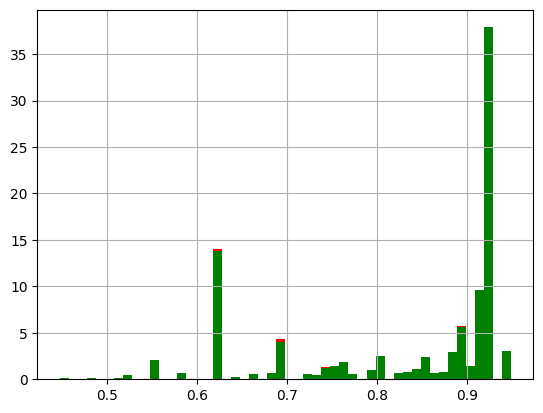

In [165]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Data before CCA
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')
# Data after CCA
new_df['city_development_index'].hist(bins=50, ax=ax, density=True, color='green')
plt.show()

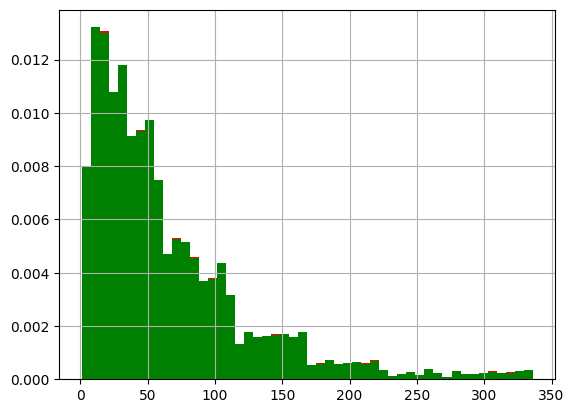

In [166]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')
new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green')
plt.show()

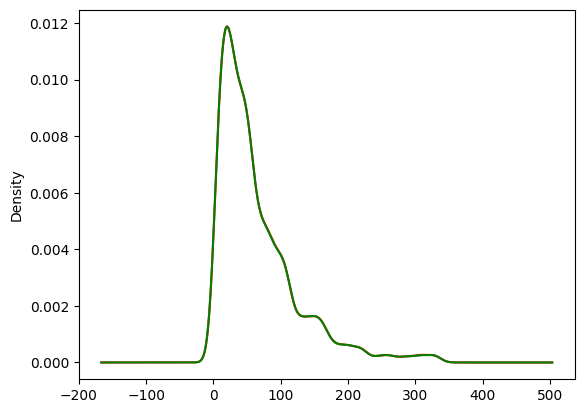

In [167]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['training_hours'].plot.density(color='red')

new_df['training_hours'].plot.density(color='green')
plt.show()

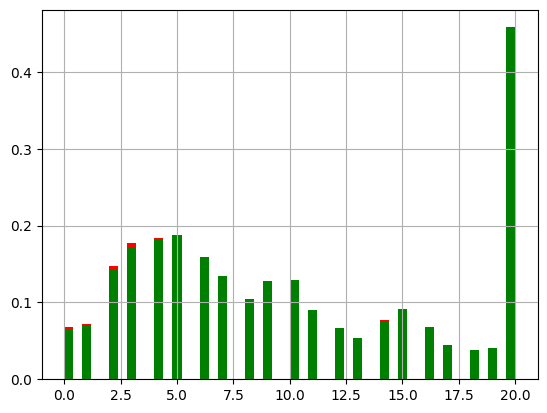

In [168]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Data before CCA
df['experience'].hist(bins=50, ax=ax, density=True, color='red')
# Data after CCA
new_df['experience'].hist(bins=50, ax=ax, density=True, color='green')
plt.show()

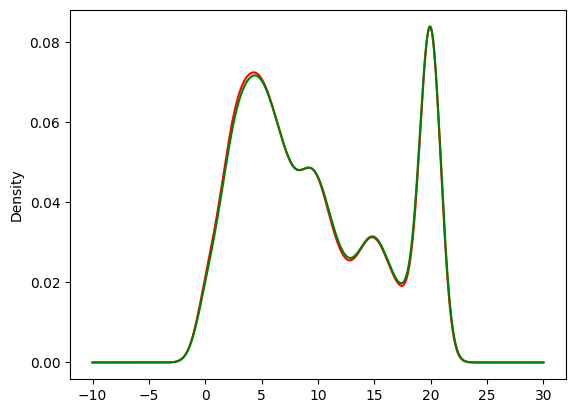

In [169]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Data before CCA
df['experience'].plot.density(color='red')
# Data after CCA
new_df['experience'].plot.density(color='green')
plt.show()

In [170]:
print('Dataset before CCA:')
print('-'*25)
print(df['enrolled_university'].value_counts())
print()
print('Dataset after CCA:')
print('-'*25)
print(new_df['enrolled_university'].value_counts())

Dataset before CCA:
-------------------------
enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

Dataset after CCA:
-------------------------
enrolled_university
no_enrollment       12632
Full time course     3449
Part time course     1101
Name: count, dtype: int64


In [171]:
print('Dataset before CCA:')
print('-'*25)
print(df['education_level'].value_counts())
print()
print('Dataset after CCA:')
print('-'*25)
print(new_df['education_level'].value_counts())

Dataset before CCA:
-------------------------
education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

Dataset after CCA:
-------------------------
education_level
Graduate          10650
Masters            4022
High School        1845
Phd                 380
Primary School      285
Name: count, dtype: int64


In [172]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(new_df)
],
axis=1)
temp.columns = ['Before CCA', 'After CCA']
temp

,Before CCA,After CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [173]:
temp = pd.concat([
    df['education_level'].value_counts() / len(df),
    new_df['education_level'].value_counts() / len(new_df)
],
axis=1)
temp.columns = ['Before CCA', 'After CCA']
temp

,Before CCA,After CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
